# AgriSense — Classification Baseline

This notebook establishes the first disease-classification baseline
for AgriSense.

The goal is to determine how well a pretrained image classification
model can classify the 115 disease classes using the original plant
images.

This baseline will provide a reference point for later improvements
such as class-weighted training, sampling strategies, and
segmentation-aware approaches.

## Model

- Architecture: ResNet-18
- Initialization: ImageNet pretrained weights
- Input size: 224 × 224
- Number of classes: 115
- Training data: AgriSense cleaned Training split
- Validation data: AgriSense cleaned Validation split
- Test data: AgriSense cleaned Test split

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

from PIL import Image

from torchvision import models , transforms

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [6]:
#loading the preprocessing objects

project_root = Path.cwd().parent

processed_dir = project_root / "data" / "processed"

clean_metadata_path = (
    processed_dir / "agrisense_metadata_clean.csv"
)

df_clean = pd.read_csv(clean_metadata_path)


In [7]:
disease_classes = sorted(df_clean["Disease"].unique())

disease_to_id = {
    disease: idx
    for idx, disease in enumerate(disease_classes)
}

id_to_disease = {
    idx: disease
    for disease, idx in disease_to_id.items()
}

df_clean["disease_id"] = df_clean["Disease"].map(disease_to_id)

print("Number of disease classes:", len(disease_classes))
print("Missing disease IDs:", df_clean["disease_id"].isna().sum())
print("Unique disease IDs:", df_clean["disease_id"].nunique())

Number of disease classes: 115
Missing disease IDs: 0
Unique disease IDs: 115


In [8]:
print("Dataset shape:", df_clean.shape)
print("Disease classes:", df_clean["disease_id"].nunique())

Dataset shape: (7399, 12)
Disease classes: 115


In [9]:
# Recreating the split DataFrames

train_df = df_clean[
    df_clean["Split"] == "Training"
].copy()

val_df = df_clean[
    df_clean["Split"] == "Validation"
].copy()

test_df = df_clean[
    df_clean["Split"] == "Test"
].copy()

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Training: 5084
Validation: 811
Test: 1504


## Reusing my Dataset and transforms

In [10]:
# 1

class ResizeWithPadding:
    def __init__(self, size=(224, 224)):
        self.size = size

    def __call__(self, image):
        target_width, target_height = self.size

        scale = min(
            target_width / image.width,
            target_height / image.height
        )

        new_width = int(image.width * scale)
        new_height = int(image.height * scale)

        image = image.resize(
            (new_width, new_height),
            Image.Resampling.LANCZOS
        )

        canvas = Image.new(
            "RGB",
            self.size,
            (0, 0, 0)
        )

        left = (target_width - new_width) // 2
        top = (target_height - new_height) // 2

        canvas.paste(image, (left, top))

        return canvas

In [11]:
# 2 

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    ResizeWithPadding((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

val_test_transform = transforms.Compose([
    ResizeWithPadding((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [12]:
# 3

class AgriSenseDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = Path(row["actual_image_path"])

        image = Image.open(image_path).convert("RGB")
        label = int(row["disease_id"])

        if self.transform:
            image = self.transform(image)
    
        return image, label

In [13]:
def find_actual_image_path(row):
    expected_path = image_root / row["Name"]

    if expected_path.exists():
        return expected_path

    matches = list(image_root.rglob(row["Name"]))

    if len(matches) == 1:
        return matches[0]

    return None


In [14]:
image_root = (
    project_root
    / "data"
    / "raw"
    / "PlantSeg"
    / "images"
)

df_clean["actual_image_path"] = df_clean.apply(
    find_actual_image_path,
    axis=1
)

In [15]:
print(
    "Images successfully located:",
    df_clean["actual_image_path"].notna().sum()
)

print(
    "Images not located:",
    df_clean["actual_image_path"].isna().sum()
)

Images successfully located: 7399
Images not located: 0


In [16]:
train_df = df_clean[
    df_clean["Split"] == "Training"
].copy()

val_df = df_clean[
    df_clean["Split"] == "Validation"
].copy()

test_df = df_clean[
    df_clean["Split"] == "Test"
].copy()

### creating dataset and loaders

In [17]:
train_dataset = AgriSenseDataset(
    train_df,
    transform=train_transform
)

val_dataset = AgriSenseDataset(
    val_df,
    transform=val_test_transform
)

test_dataset = AgriSenseDataset(
    test_df,
    transform=val_test_transform
)

In [18]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [19]:
# checking the device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [20]:
#loading pretrained RestNet-18

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [21]:
#replacing final layers

num_classes = df_clean["disease_id"].nunique()

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=115, bias=True)


In [22]:
#for the first baseline we freeze the backbone

for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.fc.parameters():
    parameter.requires_grad = True

In [23]:
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Trainable parameters:", trainable_parameters)
print("Total parameters:", total_parameters)

Trainable parameters: 58995
Total parameters: 11235507


In [24]:
#loss and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [25]:
images, labels = next(iter(train_loader))

print("Input batch:", images.shape)
print("Labels:", labels.shape)

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Model output:", outputs.shape)

Input batch: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])
Model output: torch.Size([16, 115])


In [26]:
EPOCHS = 1

best_val_loss = float("inf")
best_model_state = None

In [39]:
# training + validation loop

train_history = []
val_history = []

# AgriSense - ResNet18 Baseline Training

# 1. Training configuration

EPOCHS = 5
BATCH_SIZE = 16

print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Device:", device)


# 2. Recreate DataLoaders with the stable batch size

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("\nDataLoaders created successfully.")
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


# 3. Create checkpoint directory

checkpoint_dir = project_root / "models" / "checkpoints"

checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True
)

latest_checkpoint_path = (
    checkpoint_dir / "resnet18_baseline_latest.pth"
)

best_checkpoint_path = (
    checkpoint_dir / "resnet18_baseline_best.pth"
)

print("\nCheckpoint directory:")
print(checkpoint_dir)


# 4. Training history

train_history = []
val_history = []

best_val_loss = float("inf")


# 5. Training loop

for epoch in range(EPOCHS):

    print("\n" + "=" * 60)
    print(f"Starting Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 60)


    # TRAINING

    model.train()

    running_train_loss = 0.0

    train_predictions = []
    train_targets = []


    train_progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )


    for images, labels in train_progress:

        # Move data to CPU/GPU
        images = images.to(device)
        labels = labels.to(device)


        # Clear previous gradients
        optimizer.zero_grad()


        # Forward pass
        outputs = model(images)


        # Calculate loss
        loss = criterion(outputs, labels)


        # Backpropagation
        loss.backward()


        # Update trainable parameters
        optimizer.step()


        # Accumulate loss
        running_train_loss += (
            loss.item() * images.size(0)
        )


        # Get predicted class
        predictions = torch.argmax(
            outputs,
            dim=1
        )


        # Store predictions and true labels
        train_predictions.extend(
            predictions.cpu().numpy()
        )

        train_targets.extend(
            labels.cpu().numpy()
        )


    # Calculate average training loss
    train_loss = (
        running_train_loss
        / len(train_loader.dataset)
    )


    # Calculate training accuracy
    train_accuracy = accuracy_score(
        train_targets,
        train_predictions
    )


    # Calculate training Macro F1
    train_f1 = f1_score(
        train_targets,
        train_predictions,
        average="macro",
        zero_division=0
    )


    # VALIDATION

    model.eval()

    running_val_loss = 0.0

    val_predictions = []
    val_targets = []


    with torch.no_grad():

        val_progress = tqdm(
            val_loader,
            desc="Validation"
        )


        for images, labels in val_progress:

            images = images.to(device)
            labels = labels.to(device)


            # Forward pass
            outputs = model(images)


            # Validation loss
            loss = criterion(
                outputs,
                labels
            )


            # Accumulate loss
            running_val_loss += (
                loss.item() * images.size(0)
            )


            # Predicted class
            predictions = torch.argmax(
                outputs,
                dim=1
            )


            # Store predictions and true labels
            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_targets.extend(
                labels.cpu().numpy()
            )


    # Calculate average validation loss
    val_loss = (
        running_val_loss
        / len(val_loader.dataset)
    )


    # Calculate validation accuracy
    val_accuracy = accuracy_score(
        val_targets,
        val_predictions
    )


    # Calculate validation Macro F1
    val_f1 = f1_score(
        val_targets,
        val_predictions,
        average="macro",
        zero_division=0
    )


    # SAVE METRICS TO HISTORY

    train_history.append({
        "epoch": epoch + 1,
        "loss": train_loss,
        "accuracy": train_accuracy,
        "macro_f1": train_f1
    })


    val_history.append({
        "epoch": epoch + 1,
        "loss": val_loss,
        "accuracy": val_accuracy,
        "macro_f1": val_f1
    })


    # SAVE LATEST CHECKPOINT

    torch.save(
        {
            "epoch": epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "train_loss":
                train_loss,

            "train_accuracy":
                train_accuracy,

            "train_macro_f1":
                train_f1,

            "val_loss":
                val_loss,

            "val_accuracy":
                val_accuracy,

            "val_macro_f1":
                val_f1,

            "num_classes":
                num_classes,

            "disease_to_id":
                disease_to_id
        },
        latest_checkpoint_path
    )


    # SAVE BEST CHECKPOINT

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_loss":
                    val_loss,

                "val_accuracy":
                    val_accuracy,

                "val_macro_f1":
                    val_f1,

                "num_classes":
                    num_classes,

                "disease_to_id":
                    disease_to_id
            },
            best_checkpoint_path
        )

        best_message = "  ✓ New best model saved!"

    else:

        best_message = ""


    # PRINT EPOCH RESULTS

    print("\nEpoch Results")
    print("-" * 60)

    print(
        f"Train Loss:     {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: {train_accuracy:.4f}"
    )

    print(
        f"Train Macro F1: {train_f1:.4f}"
    )

    print()

    print(
        f"Val Loss:       {val_loss:.4f}"
    )

    print(
        f"Val Accuracy:   {val_accuracy:.4f}"
    )

    print(
        f"Val Macro F1:   {val_f1:.4f}"
    )

    print()

    print(
        f"Latest checkpoint saved."
    )

    if best_message:
        print(best_message)

# 6. Training completed

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    f"Best Validation Loss: {best_val_loss:.4f}"
)

print(
    "\nLatest checkpoint:"
)

print(latest_checkpoint_path)

print(
    "\nBest checkpoint:"
)

print(best_checkpoint_path)

Epochs: 5
Batch size: 16
Device: cpu

DataLoaders created successfully.
Training batches: 318
Validation batches: 51
Test batches: 94

Checkpoint directory:
c:\Users\Dell\Documents\Projects\AgriSense\models\checkpoints

Starting Epoch 1/5


Epoch 1/5:   0%|          | 0/318 [00:00<?, ?it/s]

Validation: 100%|██████████| 51/51 [01:04<00:00,  1.27s/it]



Epoch Results
------------------------------------------------------------
Train Loss:     2.7333
Train Accuracy: 0.3546
Train Macro F1: 0.2417

Val Loss:       2.6181
Val Accuracy:   0.3613
Val Macro F1:   0.2247

Latest checkpoint saved.
  ✓ New best model saved!

Starting Epoch 2/5


Validation: 100%|██████████| 51/51 [01:05<00:00,  1.27s/it]


...


Epoch Results
------------------------------------------------------------
Train Loss:     2.0517
Train Accuracy: 0.4752
Train Macro F1: 0.4115

Val Loss:       2.2880
Val Accuracy:   0.4180
Val Macro F1:   0.2862

Latest checkpoint saved.
  ✓ New best model saved!

Starting Epoch 4/5


Validation: 100%|██████████| 51/51 [00:58<00:00,  1.15s/it]



Epoch Results
------------------------------------------------------------
Train Loss:     1.8765
Train Accuracy: 0.5069
Train Macro F1: 0.4756

Val Loss:       2.2476
Val Accuracy:   0.4254
Val Macro F1:   0.3072

Latest checkpoint saved.
  ✓ New best model saved!

Starting Epoch 5/5


Validation: 100%|██████████| 51/51 [00:59<00:00,  1.17s/it]


Epoch Results
------------------------------------------------------------
Train Loss:     1.7706
Train Accuracy: 0.5287
Train Macro F1: 0.5019

Val Loss:       2.2170
Val Accuracy:   0.4229
Val Macro F1:   0.2956

Latest checkpoint saved.
  ✓ New best model saved!

TRAINING COMPLETE
Best Validation Loss: 2.2170

Latest checkpoint:
c:\Users\Dell\Documents\Projects\AgriSense\models\checkpoints\resnet18_baseline_latest.pth

Best checkpoint:
c:\Users\Dell\Documents\Projects\AgriSense\models\checkpoints\resnet18_baseline_best.pth


In [28]:
checkpoint_dir = project_root / "models" / "checkpoints"

best_checkpoint_path = (
    checkpoint_dir / "resnet18_baseline_best.pth"
)

print("Checkpoint path:")
print(best_checkpoint_path)

print("\nCheckpoint exists:", best_checkpoint_path.exists())

Checkpoint path:
c:\Users\Dell\Documents\Projects\AgriSense\models\checkpoints\resnet18_baseline_best.pth

Checkpoint exists: True


In [ ]:
# Loading the best RestNet-18 baseline checkpoint

checkpoint = torch.load(
    best_checkpoint_path,
    map_location = device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Best checkpoint loaded successfully.")
print("Checkpoint epoch:", checkpoint["epoch"])
print("Validation Loss:", checkpoint["val_loss"])
print("Validation Accuracy:", checkpoint["val_accuracy"])
print("Validation Macro F1:", checkpoint["val_macro_f1"])

Best checkpoint loaded successfully.
Checkpoint epoch: 5
Validation Loss: 2.2170482657840602
Validation Accuracy: 0.42293464858199753
Validation Macro F1: 0.29562832708362424


In [30]:
# Generate Predictions on Test Set

model.eval()

test_predictions = []
test_targets = []
test_probabilities = []

with torch.no_grad():

    test_progress = tqdm(
        test_loader,
        desc="Testing"
    )

    for images, labels in test_progress:

        #Move images and labels to the selected device
        images = images.to(device)
        labels = labels.to(device)

        #Model prediction
        outputs = model(images)

        #Convert model outputs into probabilities
        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        #Get predicted disease class
        predictions = torch.argmax(
            outputs,
            dim=1
        )

        #Store predictions
        test_predictions.extend(
            predictions.cpu().numpy()
        )

        #Store actual labels
        test_targets.extend(
            labels.cpu().numpy()
        )

        #Store probabilities
        test_probabilities.extend(
            probabilities.cpu().numpy()
        )


print("\nTest prediction completed.")

print(
    "Number of test samples:",
    len(test_targets)
)

print(
    "Number of predictions:",
    len(test_predictions)
)

print(
    "Probability array shape:",
    np.array(test_probabilities).shape
)

Testing: 100%|██████████| 94/94 [02:28<00:00,  1.57s/it]


Test prediction completed.
Number of test samples: 1504
Number of predictions: 1504
Probability array shape: (1504, 115)


In [31]:
#Test Set Evaluation

test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

test_macro_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    test_targets,
    test_predictions,
    average="weighted",
    zero_division=0
)


print("=" * 60)
print("AgriSense - ResNet18 Baseline Test Results")
print("=" * 60)

print(
    f"Test Accuracy:     {test_accuracy:.4f}"
)

print(
    f"Test Macro F1:     {test_macro_f1:.4f}"
)

print(
    f"Test Weighted F1:  {test_weighted_f1:.4f}"
)

AgriSense - ResNet18 Baseline Test Results
Test Accuracy:     0.4402
Test Macro F1:     0.3399
Test Weighted F1:  0.4237


In [33]:
# Classification Report - All Disease Classes

classification_report_text = classification_report(
    test_targets,
    test_predictions,
    labels = list(range(num_classes)),
    target_names = [
        id_to_disease[i]
        for i in range(num_classes)
    ],
    zero_division = 0
)

print(classification_report_text)

                                           precision    recall  f1-score   support

                          apple black rot       0.33      0.33      0.33        12
                       apple mosaic virus       0.20      0.23      0.21        13
                               apple rust       0.00      0.00      0.00        22
                               apple scab       0.42      0.49      0.45        35
                       banana anthracnose       0.42      0.89      0.57         9
                 banana black leaf streak       0.69      0.75      0.72        24
                        banana bunchy top       0.67      0.62      0.64        13
                     banana cigar end rot       0.75      0.33      0.46         9
                 banana cordana leaf spot       0.50      0.38      0.43         8
                    banana panama disease       0.83      0.50      0.62        10
                       basil downy mildew       0.55      0.60      0.57        10
   

In [34]:
# Classification Report DataFrame

report_dict = classification_report(
    test_targets,
    test_predictions,
    labels=list(range(num_classes)),
    target_names=[
        id_to_disease[i]
        for i in range(num_classes)
    ],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

# Keeping only actual disease classes
disease_report_df = report_df.iloc[:num_classes].copy()

# Adding disease name as a column
disease_report_df.index.name = "Disease"
disease_report_df = disease_report_df.reset_index()

print("Disease-level evaluation table created.")

print(
    "Number of disease classes:",
    len(disease_report_df)
)

disease_report_df.head(10)

Disease-level evaluation table created.
Number of disease classes: 115


,Disease,precision,recall,f1-score,support
0,apple black rot,0.333333,0.333333,0.333333,12.0
1,apple mosaic virus,0.200000,0.230769,0.214286,13.0
2,apple rust,0.000000,0.000000,0.000000,22.0
3,apple scab,0.425000,0.485714,0.453333,35.0
4,banana anthracnose,0.421053,0.888889,0.571429,9.0
5,banana black leaf streak,0.692308,0.750000,0.720000,24.0
6,banana bunchy top,0.666667,0.615385,0.640000,13.0
7,banana cigar end rot,0.750000,0.333333,0.461538,9.0
8,banana cordana leaf spot,0.500000,0.375000,0.428571,8.0
9,banana panama disease,0.833333,0.500000,0.625000,10.0


In [35]:
# Creating a disease level evaluation table

report_dict = classification_report(
    test_targets,
    test_predictions,
    labels=list(range(num_classes)),
    target_names=[id_to_disease[i] for i in range(num_classes)],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

disease_report_df = report_df.iloc[:num_classes].copy()
disease_report_df.index.name = "Disease"
disease_report_df = disease_report_df.reset_index()

print("Disease-level evaluation table created.")
print("Number of disease classes:", len(disease_report_df))

disease_report_df.head(10)

Disease-level evaluation table created.
Number of disease classes: 115


,Disease,precision,recall,f1-score,support
0,apple black rot,0.333333,0.333333,0.333333,12.0
1,apple mosaic virus,0.200000,0.230769,0.214286,13.0
2,apple rust,0.000000,0.000000,0.000000,22.0
3,apple scab,0.425000,0.485714,0.453333,35.0
4,banana anthracnose,0.421053,0.888889,0.571429,9.0
5,banana black leaf streak,0.692308,0.750000,0.720000,24.0
6,banana bunchy top,0.666667,0.615385,0.640000,13.0
7,banana cigar end rot,0.750000,0.333333,0.461538,9.0
8,banana cordana leaf spot,0.500000,0.375000,0.428571,8.0
9,banana panama disease,0.833333,0.500000,0.625000,10.0


In [36]:
# Sorting the diseases by F1 Score

f1_sorted = disease_report_df.sort_values(
    by="f1-score",
    ascending=False
)

print("Top 10 diseases by F1-score:")
display(
    f1_sorted[
        ["Disease", "precision", "recall", "f1-score", "support"]
    ].head(10)
)

print("\nBottom 10 diseases by F1-score:")
display(
    f1_sorted[
        ["Disease", "precision", "recall", "f1-score", "support"]
    ].tail(10)
)

Top 10 diseases by F1-score:


,Disease,precision,recall,f1-score,support
30,carrot cavity spot,1.000000,0.888889,0.941176,9.0
15,bell pepper blossom end rot,0.750000,0.750000,0.750000,16.0
5,banana black leaf streak,0.692308,0.750000,0.720000,24.0
27,cabbage black rot,0.652174,0.789474,0.714286,19.0
47,corn smut,0.937500,0.576923,0.714286,26.0
38,citrus canker,0.608696,0.861538,0.713376,65.0
104,wheat head scab,0.634615,0.767442,0.694737,43.0
18,blueberry anthracnose,0.600000,0.750000,0.666667,4.0
90,strawberry anthracnose,0.545455,0.857143,0.666667,7.0
61,grapevine leafroll disease,0.750000,0.600000,0.666667,5.0



Bottom 10 diseases by F1-score:


,Disease,precision,recall,f1-score,support
57,ginger sheath blight,0.0,0.0,0.0,11.0
65,peach anthracnose,0.0,0.0,0.0,2.0
51,eggplant cercospora leaf spot,0.0,0.0,0.0,4.0
77,raspberry fire blight,0.0,0.0,0.0,4.0
72,plum pocket disease,0.0,0.0,0.0,4.0
74,plum rust,0.0,0.0,0.0,4.0
70,plum bacterial spot,0.0,0.0,0.0,3.0
91,strawberry leaf scorch,0.0,0.0,0.0,3.0
100,tomato mosaic virus,0.0,0.0,0.0,8.0
112,zucchini downy mildew,0.0,0.0,0.0,5.0


In [37]:
# Comparing F1 against Class Support

support_f1_analysis = disease_report_df[
    ["Disease", "f1-score", "support"]
].copy()

support_f1_analysis["support_group"] = pd.cut(
    support_f1_analysis["support"],
    bins=[0, 5, 10, 20, 50, float("inf")],
    labels=["1-5", "6-10", "11-20", "21-50", "51+"]
)

support_summary = (
    support_f1_analysis
    .groupby("support_group", observed=False)
    .agg(
        number_of_diseases=("Disease", "count"),
        mean_f1=("f1-score", "mean"),
        median_f1=("f1-score", "median"),
        zero_f1_classes=("f1-score", lambda x: (x == 0).sum())
    )
    .reset_index()
)

support_summary

,support_group,number_of_diseases,mean_f1,median_f1,zero_f1_classes
0,1-5,31,0.193604,0.000000,18
1,6-10,27,0.343398,0.333333,4
2,11-20,35,0.376899,0.333333,1
3,21-50,20,0.478509,0.515357,1
4,51+,1,0.713376,0.713376,0


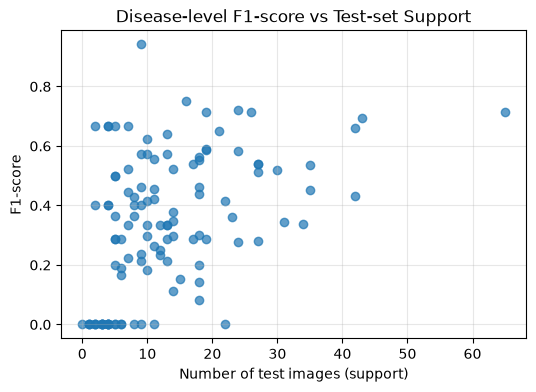

In [39]:
# Visualize

plt.figure(figsize=(6, 4))

plt.scatter(
    support_f1_analysis["support"],
    support_f1_analysis["f1-score"],
    alpha=0.7
)

plt.xlabel("Number of test images (support)")
plt.ylabel("F1-score")
plt.title("Disease-level F1-score vs Test-set Support")
plt.grid(alpha=0.3)

plt.show()

In [40]:
pearson_corr = support_f1_analysis["support"].corr(
    support_f1_analysis["f1-score"],
    method="pearson"
)

spearman_corr = support_f1_analysis["support"].corr(
    support_f1_analysis["f1-score"],
    method="spearman"
)

print(f"Pearson correlation:  {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation:  0.452
Spearman correlation: 0.478
